## Support Vector Machines


In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import loguniform
from scipy.stats import uniform
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold

In [29]:
df = pd.read_csv('../train_set/train_cleaned_outliers.csv')
test = pd.read_csv('../test_set/test_no_title.csv')
train = df.drop(columns=['originalTitle'])

In [30]:
# change all 1, 2, 3 in 4
train['rating'] = train['rating'].replace([1, 2, 3], 4)
test['rating'] = test['rating'].replace([1, 2, 3], 4)

# replace all 10 with 9
train['rating'] = train['rating'].replace(10, 9)
test['rating'] = test['rating'].replace(10, 9)


In [31]:
X_train = train.drop(columns=['rating', 'averageRating'])
y_train = train['rating']

X_test = test.drop(columns=['rating', 'averageRating', 'genreShort'])
y_test = test['rating']

In [32]:
num_cols = [
    'titleType',
    'numVotes', 
    'startYearDecade', 
    'runtimeHours',
    'totalCredits',
    'criticReviewsTotal',
    'userReviewsTotal',
    'castNumber',
    'companiesNumber',
    'writerCredits',
    'directorsCredits',
    'quotesTotal',
    'totalMedia',
    'totalRecognitions',
    ]

one_hot_cols = [
    "genreFamily", "genreDocumentary", "genreNews", "genreFilm-Noir", "genreWestern",
    "genreFantasy", "genreAdult", "genreAction", "genreMusic", "genreComedy",
    "genreSport", "genreHorror", "genreBiography", "genreTalk-Show",
    "genreDrama", "genreRomance", "genreWar", "genreMystery", "genreHistory",
    "genreSci-Fi", "genreAnimation", "genreAdventure", "genreReality-TV",
    "genreMusical", "genreThriller", "genreGame-Show", "genreCrime"
]

In [33]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Range ampio centrato sul best_C con espansione logaritmica
param_dist_halving_linear = {
    'C': loguniform(1e-2,6),  # Range logaritmico ampio ±10x
    'class_weight': ['balanced'],  # Testa entrambi
    'loss': ['hinge', 'squared_hinge'],  # Entrambe le loss functions
    'penalty': ['l2', 'l1'],  # L1 e L2 regularization
    'max_iter': [300000, 400000, 500000],  # Diverse iterazioni per convergenza
    'tol': [1e-3, 1e-4],  # Diverse tolleranze
}

linear_svc_explorer = LinearSVC(
    random_state=42)

# HalvingRandomSearchCV ottimizzato per LinearSVC
search_linear = HalvingRandomSearchCV(
    linear_svc_explorer,
    param_dist_halving_linear,
    factor=1.2,  # Elimina 2/3 dei candidati ad ogni iterazione
    resource='n_samples',  # Usa campioni crescenti
    max_resources='auto',  # Usa tutti i campioni nell'ultima iterazione
    scoring='f1_macro', 
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search_linear.fit(X_train_scaled, y_train)

n_iterations: 37
n_required_iterations: 37
n_possible_iterations: 37
min_resources_: 120
max_resources_: 93240
aggressive_elimination: False
factor: 1.2
----------
iter: 0
n_candidates: 777
n_resources: 120
Fitting 10 folds for each of 777 candidates, totalling 7770 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1860 fits failed out of a total of 7770.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1860 fits failed with the following error:
Traceback (most recent call last):
  File "/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/

----------
iter: 1
n_candidates: 648
n_resources: 144
Fitting 10 folds for each of 648 candidates, totalling 6480 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
570 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
570 fits failed with the following error:
Traceback (most recent call last):
  File "/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sk

----------
iter: 2
n_candidates: 540
n_resources: 172
Fitting 10 folds for each of 540 candidates, totalling 5400 fits


...

----------
iter: 35
n_candidates: 5
n_resources: 70880
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the test scores are non-finite: [0.14135714 0.11363757 0.12705462 ... 0.27472903 0.27473274 0.27474524]
  warnings.warn(
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the train scores are non-finite: [0.50302309 0.55955366 0.08690339 ... 0.27752934 0.27752994 0.27752728]
  warnings.warn(


----------
iter: 36
n_candidates: 5
n_resources: 85056
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the test scores are non-finite: [0.14135714 0.11363757 0.12705462 ... 0.27563903 0.27563204 0.27563809]
  warnings.warn(
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the train scores are non-finite: [0.50302309 0.55955366 0.08690339 ... 0.277365   0.27737376 0.27737297]
  warnings.warn(


HalvingRandomSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                      estimator=LinearSVC(random_state=42), factor=1.2,
                      n_jobs=-1,
                      param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x711cecab3af0>,
                                           'class_weight': ['balanced'],
                                           'loss': ['hinge', 'squared_hinge'],
                                           'max_iter': [300000, 400000, 500000],
                                           'penalty': ['l2', 'l1'],
                                           'tol': [0.001, 0.0001]},
                      random_state=42, scoring='f1_macro', verbose=1)

In [46]:
best_model = search_linear.best_estimator_
joblib.dump(best_model, './models/svm_rating.pkl')

['./models/svm_rating.pkl']

In [47]:
best_model = joblib.load('./models/svm_rating.pkl')
# print parameters
print("Best parameters found: ", search_linear.best_params_)


Best parameters found:  {'C': 1.5198303466296808, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 400000, 'penalty': 'l2', 'tol': 0.0001}


In [48]:
y_pred = best_model.predict(X_test_scaled)

test_f1_score = f1_score(y_test, y_pred, average='weighted')
train_f1_score = f1_score(y_train, best_model.predict(X_train_scaled), average='weighted')

print(f"Train F1 score: {train_f1_score:.6f}")
print(f"Test F1 score: {test_f1_score:.6f}")

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train F1 score: 0.328551
Test F1 score: 0.325862

Classification Report:
              precision    recall  f1-score   support

           4       0.12      0.32      0.17      1184
           5       0.17      0.20      0.18      2199
           6       0.28      0.37      0.32      5090
           7       0.36      0.11      0.17      9375
           8       0.46      0.56      0.51     11892
           9       0.31      0.30      0.30      6555

    accuracy                           0.34     36295
   macro avg       0.28      0.31      0.28     36295
weighted avg       0.35      0.34      0.33     36295



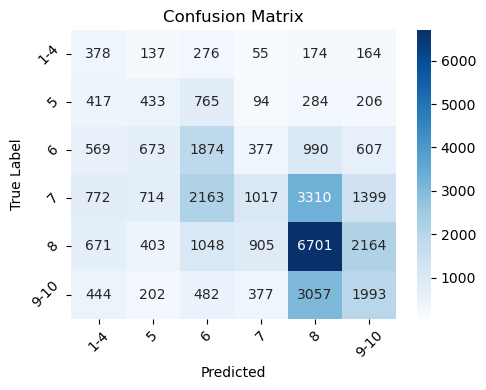

In [ ]:
# ...existing code...
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))

# Crea le label per gli assi usando il mapping
class_labels = [label_map[i] for i in range(len(label_map))]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels,  # Label testuali per asse X
    yticklabels=class_labels   # Label testuali per asse Y
)

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.tight_layout()  # Per migliorare il layout
plt.show()


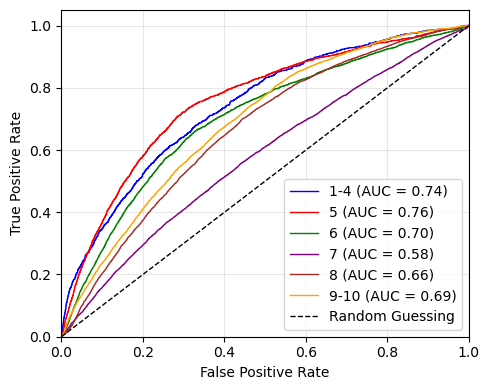


ROC AUC per classe:
1-4: 0.739
5: 0.756
6: 0.701
7: 0.577
8: 0.663
9-10: 0.689

ROC AUC media: 0.687


In [ ]:

# Binarizza solo le etichette di test
y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

# Usa predict_proba per ottenere le probabilità
y_pred_proba = best_model.decision_function(X_test_scaled)

# Calcola le curve ROC e AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot delle curve ROC
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'purple', 'brown', 'orange']

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], 
        color=colors[i % len(colors)],
        lw=1,
        label=f'{label_map[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcola anche la ROC AUC media
print(f"\nROC AUC per classe:")
for i in range(n_classes):
    print(f"{label_map[i]}: {roc_auc[i]:.3f}")
print(f"\nROC AUC media: {np.mean(list(roc_auc.values())):.3f}")
# ...existing code...